# Data Standardization

Standardization is a key preprocessing step in machine learning.  
It ensures that all numeric features contribute equally to the model by putting them on the same scale.

### Why it matters
Many algorithms (such as Logistic Regression, SVM, and KNN) rely on distance or gradient-based optimization.  
If features have very different ranges (e.g., *age* in years vs. *income* in thousands),  
the model may give more weight to variables with larger magnitudes simply because of their scale, not because they are more important.

### What standardization does
It rescales each feature so that:
\[
\tilde{x} = \frac{x - \mu}{\sigma}
\]

- **μ** = mean of the feature  
- **σ** = standard deviation of the feature  

After transformation:
- Each feature has approximately **mean = 0**  
- Each feature has approximately **standard deviation = 1**

In [26]:
import numpy as np                                    # Numerical operations and arrays
import pandas as pd                                   # Data manipulation and analysis
import seaborn as sns                                 # Visualization library built on Matplotlib
import matplotlib.pyplot as plt                       # Plotting framework

from sklearn.datasets import load_breast_cancer       # Built-in dataset for examples
from sklearn.model_selection import train_test_split  # Split data into train/test sets
from sklearn.preprocessing import StandardScaler      # Standardize numeric features

### 1) Load and Split the Dataset  

The Breast Cancer dataset is loaded from scikit-learn, where each record represents a patient’s tumor sample described by several **numerical features** such as mean radius, texture, and smoothness.  
- Each feature is continuous and measured on a different scale, which later motivates the need for standardization.  

The dataset is then divided into two parts:
- **Training set (80%):**  used for learning patterns from the data.  
- **Testing set (20%):** used to evaluate how well the model generalizes.  

In [27]:
# Load the Breast Cancer dataset from scikit-learn's built-in library
data = load_breast_cancer()

# Convert the data into a pandas DataFrame for better readability and manipulation
df = pd.DataFrame(data.data, columns=data.feature_names)

# Separate input features (X) and output labels (y)
# X contains all numeric measurements describing the tumor
# y contains the target class (0 = benign, 1 = malignant)
X, y = df.values, data.target

# Split data into training (80%) and testing (20%) subsets
# 'stratify=y' ensures that the ratio of malignant to benign cases stays balanced
# 'random_state=3' guarantees reproducibility of the random split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=3
)

# Print dataset structure and sample counts
print("Full dataset shape (rows, columns):", df.shape)
print("Training feature matrix shape:", X_train.shape)
print("Testing feature matrix shape :", X_test.shape)
print("Training label vector length :", y_train.shape)
print("Testing label vector length  :", y_test.shape)

# Verify class balance in both sets
print("\nClass distribution in full dataset:")
print(pd.Series(y).value_counts(normalize=True).map("{:.2%}".format))

print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True).map("{:.2%}".format))

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts(normalize=True).map("{:.2%}".format))

Full dataset shape (rows, columns): (569, 30)
Training feature matrix shape: (455, 30)
Testing feature matrix shape : (114, 30)
Training label vector length : (455,)
Testing label vector length  : (114,)

Class distribution in full dataset:
1    62.74%
0    37.26%
Name: proportion, dtype: object

Class distribution in training set:
1    62.64%
0    37.36%
Name: proportion, dtype: object

Class distribution in test set:
1    63.16%
0    36.84%
Name: proportion, dtype: object


## 2) Visualize a Feature Before Standardization

Before applying standardization, it is important to visualize the raw distribution of a feature.  
- This helps understand whether the feature is centered around zero, how spread out it is,  
and whether there are outliers that could affect scaling.

The first numerical column from the dataset is selected for inspection.  
- A histogram with a Kernel Density Estimate (KDE) overlay shows how the data values are distributed.

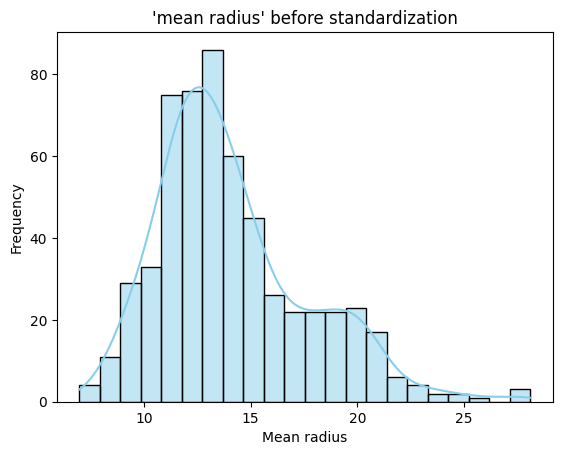

In [28]:
# Select the first numerical feature from the dataset for visualization
col = df.columns[0]

# Plot a histogram with KDE (smoothed curve) to show the data distribution
sns.histplot(df[col], kde=True, color="skyblue")

# Add a descriptive title for clarity
plt.title(f"'{col}' before standardization")

# Label axes for better interpretation
plt.xlabel(col.capitalize())
plt.ylabel("Frequency")

# Display the figure
plt.show()

### 3) Standardize the Features

The `StandardScaler` from scikit-learn standardizes features so that each one has a **mean of 0** and a **standard deviation of 1**.  
- This transformation ensures that all numeric columns are on a comparable scale, which helps many algorithms (like logistic regression, SVM, and KNN) perform better and converge faster.

#### How It Works

1. **Fit phase:**  
   The scaler computes the mean (`μ`) and standard deviation (`σ`) of each feature using only the **training data**.  

2. **Transform phase:**  
   Every feature value is then rescaled using the formula:

   $$
   \tilde{x} = \frac{x - \mu}{\sigma}
   $$

   This transformation centers the data around zero (mean = 0) and adjusts its spread so that most values fall between -1 and 1.

3. **Apply to both train and test sets:**  
   The same mean and standard deviation learned from the **training data** are applied to the **testing data**.  
   - This is critical to avoid **data leakage**, where information from the test set could unintentionally influence the training process.

In [29]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data to learn mean and standard deviation
scaler.fit(X_train)

# Apply the same transformation to both training and test sets
X_train_std = scaler.transform(X_train)
X_test_std  = scaler.transform(X_test)

# Create a small summary table to verify that features have mean ≈ 0 and std ≈ 1
summary = pd.DataFrame({
    "train_mean": X_train_std.mean(axis=0),
    "train_std":  X_train_std.std(axis=0, ddof=0)
}).round(3).head(10)

# Display the first 10 standardized features’ mean and std
print("Verification of standardization (first 10 features):")
display(summary)

Verification of standardization (first 10 features):


,train_mean,train_std
0,-0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,-0.0,1.0
5,-0.0,1.0
6,-0.0,1.0
7,0.0,1.0
8,-0.0,1.0
9,0.0,1.0


### 4) Visualize the Effect of Standardization

To understand the effect of standardization, compare the distribution of a single feature before and after scaling.

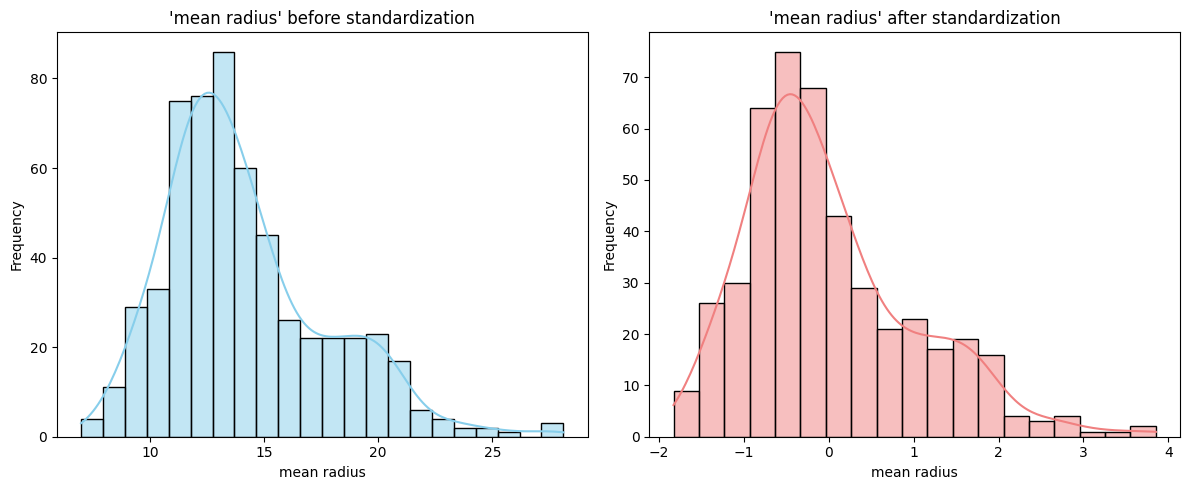

In [30]:
# Select a numeric feature to visualize
col = df.columns[0]

# Plot the feature before and after scaling side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before standardization
sns.histplot(df[col], kde=True, color="skyblue", ax=ax[0])
ax[0].set_title(f"'{col}' before standardization")
ax[0].set_xlabel(col)
ax[0].set_ylabel("Frequency")

# After standardization (first column of X_train_std)
sns.histplot(X_train_std[:, 0], kde=True, color="lightcoral", ax=ax[1])
ax[1].set_title(f"'{col}' after standardization")
ax[1].set_xlabel(col)
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()